# Markov Models para Inteligencia Artificial
**Curso:** Inteligencia Artificial · Universidad Tecnológica de Bolívar
**Referencias:** Russell & Norvig (AIMA 4ª ed.), caps. 13, 14 y 17 · Jurafsky & Martin (SLP3), N-gram LM y Apéndice A (HMM)

**Al terminar este notebook podrás:**
- Simular cadenas de Markov y calcular su distribución estacionaria.
- Entrenar y evaluar un modelo de lenguaje de bigramas.
- Implementar desde cero los algoritmos Forward, Forward-Backward y Viterbi.
- Estimar un HMM con MLE y con Baum-Welch.
- Filtrar estados continuos con Kalman y con filtro de partículas.
- Muestrear con MCMC (Metropolis-Hastings y Gibbs).
- Resolver un MDP con iteración de valor y un POMDP sencillo con estados de creencia.
- Relacionar la decodificación de un LLM con una cadena de Markov.

**Cómo trabajar:** ejecuta cada celda en orden y responde las preguntas marcadas con ✍️ en tu bitácora.

## 0. Configuración

In [1]:
# Si falta alguna librería:  pip install numpy matplotlib hmmlearn
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import itertools, math, random

# Paleta del curso
NAVY, GREEN, GRAY = "#2C4293", "#098559", "#2CB5E0"   # paleta plantilla UTB (azul, verde, cian)
LIME = "#A0CE3A"
plt.rcParams.update({"figure.figsize": (8, 3.6), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)
print("NumPy", np.__version__)

NumPy 2.4.4


## 1. Cadenas de Markov
- **Estado:** el clima del día, `sol` o `lluvia`.
- **Propiedad de Markov:** $P(X_t \mid X_{0:t-1}) = P(X_t \mid X_{t-1})$.
- **Matriz de transición:** $T_{ij} = P(X_{t+1}=j \mid X_t=i)$; cada fila suma 1.
- **Propagación:** $p_{t+1} = p_t\,T$.
- **Distribución estacionaria:** $\pi = \pi T$.

In [2]:
S = ["sol", "lluvia"]
T = np.array([[0.9, 0.1],
              [0.3, 0.7]])
assert np.allclose(T.sum(axis=1), 1), "cada fila debe sumar 1"

def simular(T, x0, pasos, rng):
    x, camino = x0, [x0]
    for _ in range(pasos):
        x = rng.choice(len(T), p=T[x])
        camino.append(x)
    return np.array(camino)

camino = simular(T, 0, 60, rng)
print(" ".join("☀" if x == 0 else "☂" for x in camino))
print("Fracción de días con sol:", round(1 - camino.mean(), 3))

☀ ☀ ☀ ☀ ☀ ☀ ☂ ☂ ☂ ☀ ☀ ☀ ☂ ☂ ☂ ☂ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☂ ☂ ☂ ☀ ☀ ☀ ☀ ☀ ☀ ☂ ☂ ☂ ☂ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀ ☀
Fracción de días con sol: 0.77


Distribución estacionaria π = [0.75 0.25]


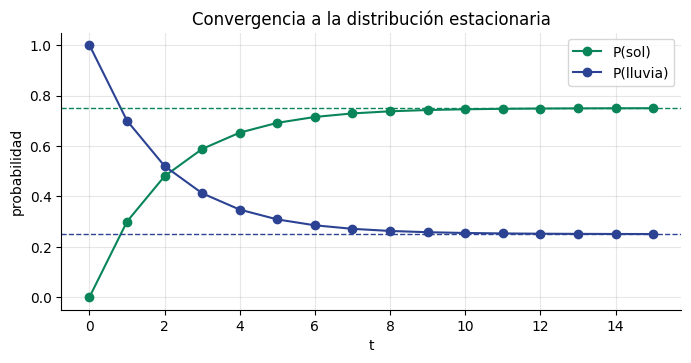

In [3]:
# Propagación de la distribución y convergencia a la estacionaria
p = np.array([0.0, 1.0])            # empezamos con certeza de lluvia
hist = [p]
for t in range(15):
    p = p @ T
    hist.append(p)
hist = np.array(hist)

w, v = np.linalg.eig(T.T)
pi = np.real(v[:, np.isclose(w, 1)]).ravel(); pi /= pi.sum()
print("Distribución estacionaria π =", pi.round(3))

plt.plot(hist[:, 0], "o-", color=GREEN, label="P(sol)")
plt.plot(hist[:, 1], "o-", color=NAVY, label="P(lluvia)")
plt.axhline(pi[0], ls="--", color=GREEN, lw=1); plt.axhline(pi[1], ls="--", color=NAVY, lw=1)
plt.xlabel("t"); plt.ylabel("probabilidad"); plt.title("Convergencia a la distribución estacionaria")
plt.legend(); plt.show()

✍️ **Preguntas**
1. Cambia `T` a `[[0.5, 0.5], [0.5, 0.5]]`. ¿Qué pasa con la convergencia?
2. Prueba `T = [[0, 1], [1, 0]]`. ¿Converge? ¿Qué propiedad falla?

### 1.1 PageRank: una cadena de Markov sobre la web
- El surfista aleatorio sigue un enlace con probabilidad $d$ o salta a cualquier página con $1-d$.
- El PageRank es la distribución estacionaria de esa cadena.

In [4]:
paginas = ["A", "B", "C", "D", "E"]
enlaces = {"A": ["B", "C"], "B": ["C"], "C": ["A"], "D": ["C", "E"], "E": ["A", "D"]}
n, d = len(paginas), 0.85
idx = {p: i for i, p in enumerate(paginas)}
M = np.zeros((n, n))
for p, outs in enlaces.items():
    for q in outs:
        M[idx[p], idx[q]] = 1 / len(outs)
G = d * M + (1 - d) / n
r = np.full(n, 1 / n)
for _ in range(100):
    r = r @ G
for p in sorted(paginas, key=lambda p: -r[idx[p]]):
    print(f"{p}: {r[idx[p]]:.3f}")

C: 0.358
A: 0.356
B: 0.181
D: 0.052
E: 0.052


## 2. Modelo de lenguaje de bigramas
- **Supuesto de Markov en texto:** $P(w_k \mid w_{1:k-1}) \approx P(w_k \mid w_{k-1})$.
- **MLE:** $P(w_k \mid w_{k-1}) = C(w_{k-1} w_k) / C(w_{k-1})$.
- **Laplace:** $(C+1)/(C(w_{k-1}) + V)$.
- **Perplejidad:** $PP = P(w_{1:N})^{-1/N}$.

In [5]:
corpus = '''la inteligencia artificial estudia agentes inteligentes
los agentes perciben el entorno y actúan sobre el entorno
un modelo de markov describe secuencias de estados
un modelo oculto de markov tiene estados ocultos y observaciones
el algoritmo de viterbi encuentra la secuencia de estados más probable
el algoritmo forward calcula la probabilidad de las observaciones
los modelos de lenguaje asignan probabilidad a secuencias de palabras
un modelo de lenguaje grande predice la siguiente palabra'''.split("\n")
oraciones = [["<s>"] + o.split() + ["</s>"] for o in corpus]
uni = Counter(w for o in oraciones for w in o)
bi = Counter((a, b) for o in oraciones for a, b in zip(o, o[1:]))
V = len(uni)
print("Vocabulario:", V, "palabras · bigramas distintos:", len(bi))

def p_bigrama(b, a, k=1.0):
    return (bi[(a, b)] + k) / (uni[a] + k * V)

def perplejidad(frase, k=1.0):
    w = ["<s>"] + frase.split() + ["</s>"]
    lp = sum(math.log(p_bigrama(b, a, k)) for a, b in zip(w, w[1:]))
    return math.exp(-lp / (len(w) - 1))

for f in ["un modelo de markov describe secuencias de estados",
          "estados de secuencias describe markov de modelo un",
          "el algoritmo de viterbi calcula la probabilidad"]:
    print(f"PP = {perplejidad(f):7.2f}   {f}")

Vocabulario: 45 palabras · bigramas distintos: 67
PP =   17.67   un modelo de markov describe secuencias de estados
PP =   49.35   estados de secuencias describe markov de modelo un
PP =   26.22   el algoritmo de viterbi calcula la probabilidad


In [6]:
def generar(max_len=15, seed=None):
    rnd = random.Random(seed)
    sig = defaultdict(list)
    for (a, b), c in bi.items():
        sig[a] += [b] * c
    w, salida = "<s>", []
    while len(salida) < max_len:
        w = rnd.choice(sig[w])
        if w == "</s>": break
        salida.append(w)
    return " ".join(salida)

for s in range(5):
    print("•", generar(seed=s))

• el algoritmo de viterbi encuentra la probabilidad a secuencias de palabras
• los agentes perciben el algoritmo forward calcula la secuencia de lenguaje asignan probabilidad a secuencias
• la inteligencia artificial estudia agentes perciben el entorno y actúan sobre el algoritmo forward calcula
• un modelo oculto de las observaciones
• un modelo de lenguaje grande predice la inteligencia artificial estudia agentes inteligentes


✍️ **Preguntas**
1. ¿Por qué la frase invertida tiene mayor perplejidad?
2. Cambia `k` (suavizado add-k) a 0.1 y a 2. ¿Cómo cambian las perplejidades?
3. ¿Qué limitación del bigrama se nota en las frases generadas?

## 3. Hidden Markov Models: el mundo del paraguas (R&N)
- **Oculto:** lluvia o seco. **Observado:** el director llega con paraguas o sin paraguas.
- $\lambda = (\pi, A, B)$ con $A$ = transición y $B$ = modelo del sensor.
- **Filtrado (Forward):** $P(X_t \mid e_{1:t})$.
- **Suavizado (Forward-Backward):** $P(X_k \mid e_{1:t})$, $k<t$.
- **Decodificación (Viterbi):** $\arg\max_{x_{1:t}} P(x_{1:t} \mid e_{1:t})$.

In [7]:
estados = ["lluvia", "seco"]
pi0 = np.array([0.5, 0.5])
A = np.array([[0.7, 0.3], [0.3, 0.7]])
B = np.array([[0.9, 0.1],      # P(paraguas | lluvia), P(sin | lluvia)
              [0.2, 0.8]])     # P(paraguas | seco),   P(sin | seco)
O = [0, 0, 1, 0, 0, 1, 1, 1, 0, 0]   # 0 = paraguas, 1 = sin paraguas

def forward(O, pi0, A, B):
    f, F = pi0.copy(), []
    for e in O:
        f = B[:, e] * (f @ A)
        f /= f.sum()
        F.append(f)
    return np.array(F)

def forward_backward(O, pi0, A, B):
    F = forward(O, pi0, A, B)
    b, S = np.ones(len(pi0)), np.zeros_like(F)
    for t in range(len(O) - 1, -1, -1):
        s = F[t] * b; S[t] = s / s.sum()
        b = A @ (B[:, O[t]] * b)
    return F, S

def viterbi(O, pi0, A, B):
    lA, lB = np.log(A), np.log(B)
    d = np.log(pi0 @ A) + lB[:, O[0]]; bp = []
    for e in O[1:]:
        c = d[:, None] + lA
        bp.append(c.argmax(0)); d = c.max(0) + lB[:, e]
    x = [int(d.argmax())]
    for b in reversed(bp): x.insert(0, int(b[x[0]]))
    return x

F, S = forward_backward(O, pi0, A, B)
print("Filtrado  P(lluvia):", F[:, 0].round(3))
print("Suavizado P(lluvia):", S[:, 0].round(3))
print("Viterbi            :", [estados[i] for i in viterbi(O, pi0, A, B)])

Filtrado  P(lluvia): [0.818 0.883 0.191 0.731 0.867 0.186 0.07  0.057 0.682 0.858]
Suavizado P(lluvia): [0.867 0.819 0.298 0.785 0.757 0.101 0.043 0.103 0.783 0.858]
Viterbi            : ['lluvia', 'lluvia', 'seco', 'lluvia', 'lluvia', 'seco', 'seco', 'seco', 'lluvia', 'lluvia']


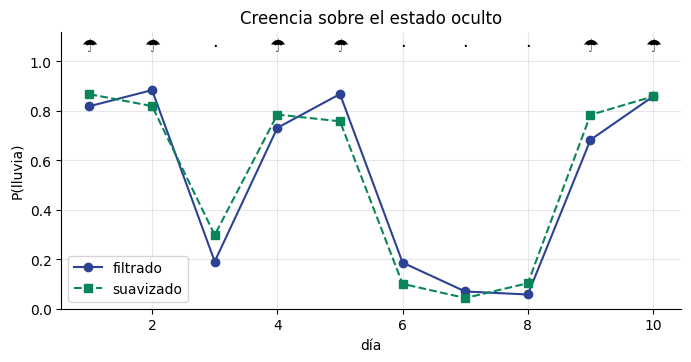

In [8]:
t = np.arange(1, len(O) + 1)
plt.plot(t, F[:, 0], "o-", color=NAVY, label="filtrado")
plt.plot(t, S[:, 0], "s--", color=GREEN, label="suavizado")
for i, e in enumerate(O):
    plt.text(t[i], 1.04, "☂" if e == 0 else "·", ha="center", fontsize=13)
plt.ylim(0, 1.12); plt.xlabel("día"); plt.ylabel("P(lluvia)")
plt.title("Creencia sobre el estado oculto"); plt.legend(loc="lower left"); plt.show()

✍️ **Preguntas**
1. Verifica que los dos primeros valores filtrados son 0.818 y 0.883 (R&N).
2. ¿En qué días difieren más el filtrado y el suavizado? ¿Por qué?
3. Cambia `B[1, 0]` (paraguas en día seco) a 0.5. ¿Qué pasa con la confianza?

## 4. HMM para PLN: etiquetado POS
- **Estados:** etiquetas UPOS. **Observaciones:** palabras.
- **Entrenamiento supervisado (MLE):** contar transiciones y emisiones, con suavizado add-k.
- **Inferencia:** Viterbi.

In [9]:
entrenamiento = [
    "el/DET perro/NOUN come/VERB carne/NOUN",
    "la/DET niña/NOUN lee/VERB un/DET libro/NOUN",
    "un/DET gato/NOUN duerme/VERB",
    "ella/PRON come/VERB rápido/ADV",
    "el/DET gato/NOUN negro/ADJ come/VERB pescado/NOUN",
    "los/DET estudiantes/NOUN leen/VERB libros/NOUN interesantes/ADJ",
    "él/PRON lee/VERB mucho/ADV",
    "la/DET profesora/NOUN explica/VERB el/DET modelo/NOUN",
]
datos = [[tuple(t.split("/")) for t in o.split()] for o in entrenamiento]
tags = sorted({t for o in datos for _, t in o})
vocab = sorted({w for o in datos for w, _ in o}) + ["<UNK>"]
ti, wi = {t: i for i, t in enumerate(tags)}, {w: i for i, w in enumerate(vocab)}
N, M, k = len(tags), len(vocab), 0.1

Pi = np.full(N, k); Ac = np.full((N, N), k); Bc = np.full((N, M), k)
for o in datos:
    Pi[ti[o[0][1]]] += 1
    for (w, t) in o: Bc[ti[t], wi[w]] += 1
    for (_, a), (_, b) in zip(o, o[1:]): Ac[ti[a], ti[b]] += 1
Pi /= Pi.sum(); Ac /= Ac.sum(1, keepdims=True); Bc /= Bc.sum(1, keepdims=True)

def etiquetar(frase):
    o = [wi.get(w, wi["<UNK>"]) for w in frase.split()]
    d = np.log(Pi) + np.log(Bc[:, o[0]]); bp = []
    for e in o[1:]:
        c = d[:, None] + np.log(Ac); bp.append(c.argmax(0))
        d = c.max(0) + np.log(Bc[:, e])
    x = [int(d.argmax())]
    for b in reversed(bp): x.insert(0, int(b[x[0]]))
    return [tags[i] for i in x]

for f in ["el perro lee un libro", "la niña come pescado rápido", "ella explica el algoritmo"]:
    print(f"{f:32s} → {etiquetar(f)}")

el perro lee un libro            → ['DET', 'NOUN', 'VERB', 'DET', 'NOUN']
la niña come pescado rápido      → ['DET', 'NOUN', 'VERB', 'ADV', 'ADV']
ella explica el algoritmo        → ['PRON', 'VERB', 'DET', 'NOUN']


✍️ **Preguntas**
1. ¿Cómo se etiqueta la palabra desconocida “algoritmo”? ¿Qué información usa el HMM?
2. En “la niña come pescado rápido”, “pescado” recibe ADV. ¿Qué transición y qué emisión explican el error?
3. Agrega 3 oraciones al corpus que lo corrijan y vuelve a ejecutar.

## 5. Aprendizaje no supervisado: Baum-Welch
- Los estados no se observan: se usa **EM**.
- **Paso E:** probabilidades esperadas con forward-backward. **Paso M:** reestimar $A$ y $B$.
- Se usa `hmmlearn` (si no está instalada, la celda lo indica).

In [10]:
try:
    from hmmlearn import hmm
except ImportError:
    hmm = None
    print("Instala hmmlearn:  pip install hmmlearn")

if hmm:
    A_real = np.array([[0.9, 0.1], [0.2, 0.8]]); B_real = np.array([[0.8, 0.2], [0.1, 0.9]])
    r2 = np.random.default_rng(0); x, obs = 0, []
    for _ in range(3000):
        x = r2.choice(2, p=A_real[x]); obs.append(r2.choice(2, p=B_real[x]))
    m = hmm.CategoricalHMM(n_components=2, n_iter=200, random_state=1)
    m.fit(np.array(obs).reshape(-1, 1))
    orden = np.argsort(m.emissionprob_[:, 0])[::-1]
    print("A real:\n", A_real, "\nA estimada:\n", m.transmat_[orden][:, orden].round(2))
    print("B real:\n", B_real, "\nB estimada:\n", m.emissionprob_[orden].round(2))

A real:
 [[0.9 0.1]
 [0.2 0.8]] 
A estimada:
 [[0.91 0.09]
 [0.23 0.77]]
B real:
 [[0.8 0.2]
 [0.1 0.9]] 
B estimada:
 [[0.8  0.2 ]
 [0.11 0.89]]


## 6. Estados continuos: filtro de Kalman y filtro de partículas
- **Kalman:** creencia gaussiana $N(\mu, \sigma^2)$; predicción + corrección con la ganancia $K$.
- **Partículas:** creencia representada por muestras; mover → ponderar → remuestrear.

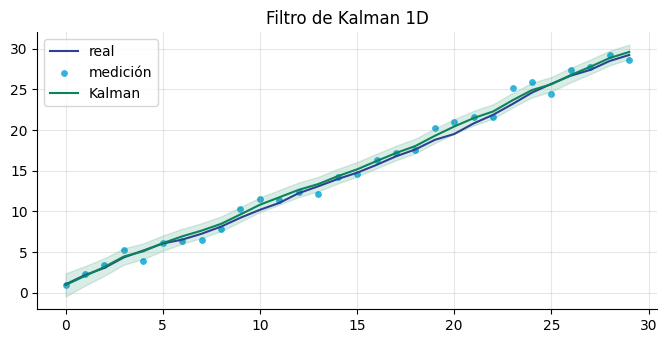

Ganancia final K = 0.2


In [11]:
r3 = np.random.default_rng(0)
Q, R, v = 0.05, 1.0, 1.0
x_real, mu, var = 0.0, 0.0, 1.0
reales, meds, mus, sds = [], [], [], []
for t in range(30):
    x_real += v + r3.normal(0, Q**0.5); z = x_real + r3.normal(0, R**0.5)
    mu, var = mu + v, var + Q
    K = var / (var + R); mu, var = mu + K * (z - mu), (1 - K) * var
    reales.append(x_real); meds.append(z); mus.append(mu); sds.append(var**0.5)
mus, sds = np.array(mus), np.array(sds)
plt.plot(reales, color=NAVY, label="real")
plt.scatter(range(30), meds, color=GRAY, s=15, label="medición")
plt.plot(mus, color=GREEN, label="Kalman")
plt.fill_between(range(30), mus - 2 * sds, mus + 2 * sds, color=GREEN, alpha=0.15)
plt.title("Filtro de Kalman 1D"); plt.legend(); plt.show()
print("Ganancia final K =", round(K, 3))

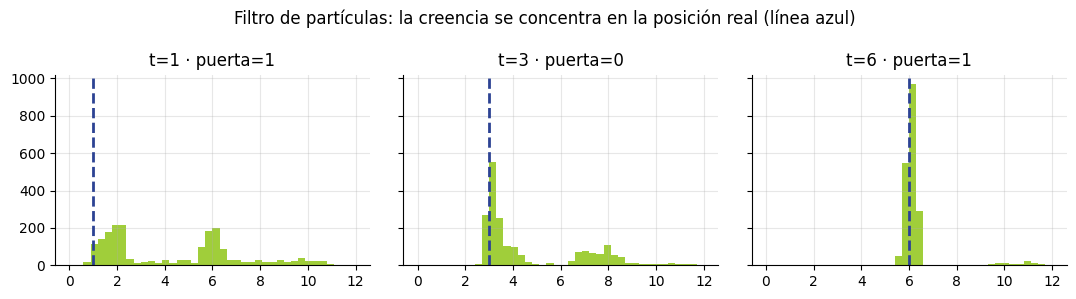

In [12]:
r4 = np.random.default_rng(3)
puertas = np.array([1.0, 2.0, 6.0])
def sensor(x):
    return np.where(np.min(np.abs(puertas[:, None] - np.atleast_1d(x)), 0) < 0.4, 0.9, 0.1)
P = r4.uniform(0, 10, 2000); x_real = 0.0
fig, ax = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for t in range(1, 7):
    x_real += 1.0; P = P + 1.0 + r4.normal(0, 0.1, P.size)
    z = r4.random() < sensor(x_real)[0]
    w = sensor(P) if z else 1 - sensor(P)
    P = r4.choice(P, P.size, p=w / w.sum())
    if t in (1, 3, 6):
        a = ax[[1, 3, 6].index(t)]
        a.hist(P, bins=40, range=(0, 12), color=LIME)
        a.axvline(x_real, color=NAVY, lw=2, ls="--"); a.set_title(f"t={t} · puerta={int(z)}")
plt.suptitle("Filtro de partículas: la creencia se concentra en la posición real (línea azul)")
plt.tight_layout(); plt.show()

## 7. MCMC: cadenas de Markov para muestrear
- Se construye una cadena cuya distribución estacionaria es la distribución objetivo.
- **Metropolis-Hastings:** aceptar $y$ con $\alpha = \min(1, \tilde p(y) / \tilde p(x))$ (propuesta simétrica).

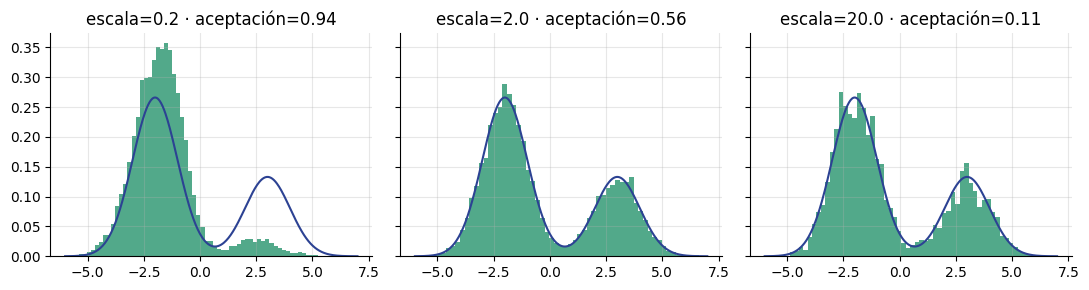

In [13]:
def p_tilde(x):
    return np.exp(-0.5 * (x + 2)**2) + 0.5 * np.exp(-0.5 * (x - 3)**2)

def metropolis(n, escala, seed=0):
    r = np.random.default_rng(seed); x, out, acc = 0.0, [], 0
    for _ in range(n):
        y = x + r.normal(0, escala)
        if r.random() < min(1, p_tilde(y) / p_tilde(x)): x, acc = y, acc + 1
        out.append(x)
    return np.array(out), acc / n

xs = np.linspace(-6, 7, 400); dens = p_tilde(xs) / getattr(np, "trapezoid", getattr(np, "trapz", None))(p_tilde(xs), xs)
fig, ax = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for a, esc in zip(ax, [0.2, 2.0, 20.0]):
    m, acc = metropolis(30_000, esc)
    a.hist(m[3000:], bins=60, density=True, color=GREEN, alpha=0.7)
    a.plot(xs, dens, color=NAVY); a.set_title(f"escala={esc} · aceptación={acc:.2f}")
plt.tight_layout(); plt.show()

✍️ **Pregunta:** ¿por qué una escala muy pequeña o muy grande mezcla mal aunque la aceptación sea alta o baja?

## 8. Procesos de Decisión de Markov: mundo 4×3
- $U(s) = \max_a \sum_{s'} P(s' \mid s,a)\,[R + \gamma U(s')]$ (ecuación de Bellman).
- La acción elegida tiene éxito con probabilidad 0.8; se desvía a los lados con 0.1 cada una.

In [14]:
F_, C_, gamma, Rv = 3, 4, 1.0, -0.04
term = {(0, 3): 1.0, (1, 3): -1.0}; pared = (1, 1)
movs = {"↑": (-1, 0), "↓": (1, 0), "←": (0, -1), "→": (0, 1)}
lat = {"↑": "←→", "↓": "←→", "←": "↑↓", "→": "↑↓"}
def mover(s, a):
    f, c = s[0] + movs[a][0], s[1] + movs[a][1]
    return s if not (0 <= f < F_ and 0 <= c < C_) or (f, c) == pared else (f, c)
Sg = [(f, c) for f in range(F_) for c in range(C_) if (f, c) != pared]
def q(s, a, U):
    return Rv + gamma * (0.8 * U[mover(s, a)] + sum(0.1 * U[mover(s, b)] for b in lat[a]))

U = {s: 0.0 for s in Sg}
for it in range(200):
    U_new = {s: term[s] if s in term else max(q(s, a, U) for a in movs) for s in Sg}
    delta = max(abs(U_new[s] - U[s]) for s in Sg); U = U_new
    if delta < 1e-6: break
print(f"convergió en {it + 1} iteraciones")
for f in range(F_):
    print(" ".join(f"{U[(f, c)]:6.3f}" if (f, c) in U else "  ####" for c in range(C_)))
print()
for f in range(F_):
    print("  ".join("+1" if (f, c) == (0, 3) else "-1" if (f, c) == (1, 3) else "##" if (f, c) == pared
                    else max(movs, key=lambda a: q((f, c), a, U)) + " " for c in range(C_)))

convergió en 30 iteraciones
 0.812  0.868  0.918  1.000
 0.762   ####  0.660 -1.000
 0.705  0.655  0.611  0.388

→   →   →   +1
↑   ##  ↑   -1
↑   ←   ←   ← 


✍️ **Pregunta:** cambia `Rv` a −0.4 y luego a −2. ¿Cómo y por qué cambia la política?

## 9. POMDP: el problema del tigre
- El estado (tigre a la izquierda o a la derecha) es oculto.
- **Creencia:** $b'(s) \propto O(o \mid s)\, b(s)$ (escuchar no mueve al tigre).
- **Decisión:** comparar $Q(b, a)$ de abrir cada puerta frente al costo de escuchar.

In [15]:
def actualizar(b, oido, acierto=0.85):
    lik = np.array([acierto, 1 - acierto]) if oido == "izq" else np.array([1 - acierto, acierto])
    b = lik * b; return b / b.sum()
def Q(b):
    return {"abrir izq": b[0] * -100 + b[1] * 10, "abrir der": b[1] * -100 + b[0] * 10, "escuchar": -1}

b = np.array([0.5, 0.5])
for oido in ["izq", "izq", "der", "izq", "izq"]:
    b = actualizar(b, oido); q_ = Q(b)
    print(f"oí {oido:3s} → b(izq)={b[0]:.3f} → mejor acción: {max(q_, key=q_.get)}")

oí izq → b(izq)=0.850 → mejor acción: escuchar
oí izq → b(izq)=0.970 → mejor acción: abrir der
oí der → b(izq)=0.850 → mejor acción: escuchar
oí izq → b(izq)=0.970 → mejor acción: abrir der
oí izq → b(izq)=0.995 → mejor acción: abrir der


## 10. Los LLM como cadenas de Markov
- Con ventana de contexto $K$, el estado es la tupla de los últimos $K$ tokens.
- Generar = recorrer una cadena de Markov con $|V|^K$ estados.
- La **temperatura**, **top-k** y **top-p** modifican la distribución de transición.

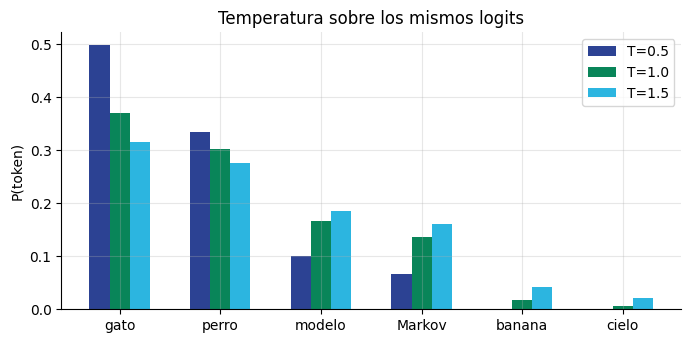

top-p=0.8 → {'gato': 0.44, 'perro': 0.36, 'modelo': 0.2, 'Markov': 0.0, 'banana': 0.0, 'cielo': 0.0}


In [16]:
vocab_llm = ["gato", "perro", "modelo", "Markov", "banana", "cielo"]
logits = np.array([2.0, 1.8, 1.2, 1.0, -1.0, -2.0])
def softmax(z, T=1.0):
    e = np.exp((z - z.max()) / T); return e / e.sum()
def top_p(p, u):
    i = np.argsort(p)[::-1]; keep = i[: np.searchsorted(np.cumsum(p[i]), u) + 1]
    q = np.zeros_like(p); q[keep] = p[keep]; return q / q.sum()

x = np.arange(len(vocab_llm)); wb = 0.2
for j, (T_, col) in enumerate([(0.5, NAVY), (1.0, GREEN), (1.5, GRAY)]):
    plt.bar(x + (j - 1) * wb, softmax(logits, T_), wb, color=col, label=f"T={T_}")
plt.xticks(x, vocab_llm); plt.ylabel("P(token)"); plt.title("Temperatura sobre los mismos logits")
plt.legend(); plt.show()
print("top-p=0.8 →", {w: round(float(p), 2) for w, p in zip(vocab_llm, top_p(softmax(logits), 0.8))})

In [17]:
# LLM de juguete con ventana K=2 sobre 3 tokens → cadena de Markov de 9 estados
Vn, K = 3, 2
ctxs = list(itertools.product(range(Vn), repeat=K))
r5 = np.random.default_rng(0)
P_sig = np.exp(r5.normal(0, 1.5, (len(ctxs), Vn)))          # "LLM": P(token | contexto)
P_sig /= P_sig.sum(1, keepdims=True)
Qm = np.zeros((len(ctxs), len(ctxs)))
for i, c in enumerate(ctxs):
    for tok in range(Vn):
        Qm[i, ctxs.index(c[1:] + (tok,))] += P_sig[i, tok]
w, v = np.linalg.eig(Qm.T)
pi_llm = np.real(v[:, np.argmax(np.real(w))]); pi_llm /= pi_llm.sum()

# Comparar con la frecuencia empírica al generar un texto largo
r6 = np.random.default_rng(1); c = ctxs[0]; cuenta = Counter()
for _ in range(50_000):
    tok = r6.choice(Vn, p=P_sig[ctxs.index(c)]); c = c[1:] + (tok,); cuenta[c] += 1
emp = np.array([cuenta[c] for c in ctxs]) / 50_000
print("estacionaria teórica:", pi_llm.round(3))
print("frecuencia generada :", emp.round(3))

estacionaria teórica: [0.067 0.141 0.14  0.129 0.11  0.108 0.152 0.096 0.056]
frecuencia generada : [0.069 0.14  0.141 0.129 0.106 0.109 0.152 0.098 0.055]


### 10.1 (Opcional) Un LLM real
- Si tienes `transformers` y acceso a Internet, la celda descarga GPT-2 y muestra la distribución del siguiente token.
- Si no, la celda se omite sin error.

In [18]:
try:
    from transformers import AutoTokenizer, AutoModelForCausalLM
    import torch
    tok = AutoTokenizer.from_pretrained("gpt2"); lm = AutoModelForCausalLM.from_pretrained("gpt2")
    ids = tok("The weather today is", return_tensors="pt").input_ids
    with torch.no_grad():
        z = lm(ids).logits[0, -1]
    p = torch.softmax(z, -1); top = torch.topk(p, 8)
    for pr, i in zip(top.values, top.indices):
        print(f"{tok.decode(int(i))!r:12s} {float(pr):.3f}")
except Exception as e:
    print("Sección opcional omitida:", type(e).__name__)

Sección opcional omitida: ModuleNotFoundError


## 11. Cierre
- **Estable:** propiedad de Markov, Forward, Viterbi, EM, Bellman.
- **Evolutivo:** librerías (`hmmlearn`, `sklearn-crfsuite`, `transformers`).
- **Emergente:** LLM como cadenas de Markov, RLHF como MDP, agentes como POMDP.

✍️ **Reto final:** elige una tarea de secuencias de tu proyecto integrador. Compara un HMM con un LLM (zero-shot) en exactitud, costo y latencia, y documenta el uso de IA en tu bitácora humano-IA.